In [13]:
# CELL 1 — All imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

print("Libraries loaded successfully")

Libraries loaded successfully


In [14]:
df = pd.read_csv("heart_cleveland_upload.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [18]:
# CELL 3 — Basic inspection
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
# INSIGHT: This dataset has no missing values — no cleaning needed

Shape: (297, 14)

Column names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']

Missing values:
 age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64


In [16]:
# CELL 4 — Summary statistics
df.describe()
# INSIGHT: Look at mean age (~54), chol (~246), thalach (~149)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


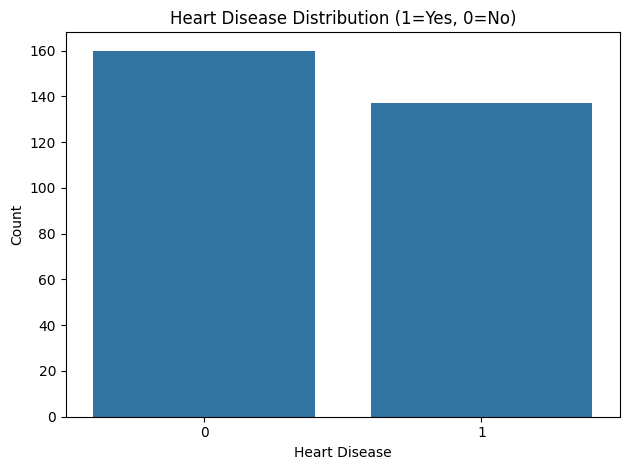

In [19]:
# CELL 5 — EDA: How many people have heart disease?
sns.countplot(x='condition', data=df)
plt.title("Heart Disease Distribution (1=Yes, 0=No)")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
# INSIGHT: Dataset is roughly balanced — good for classification

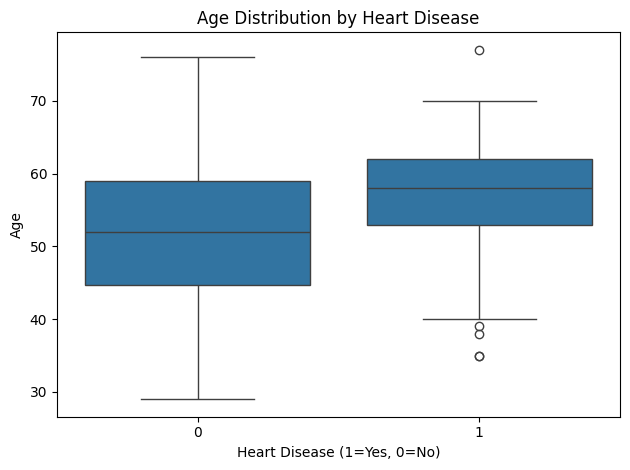

In [20]:
# CELL 6 — EDA: Age vs Heart Disease
sns.boxplot(x='condition', y='age', data=df)
plt.title("Age Distribution by Heart Disease")
plt.xlabel("Heart Disease (1=Yes, 0=No)")
plt.ylabel("Age")
plt.tight_layout()
plt.show()
# INSIGHT: Younger patients slightly more likely to have heart disease in this dataset

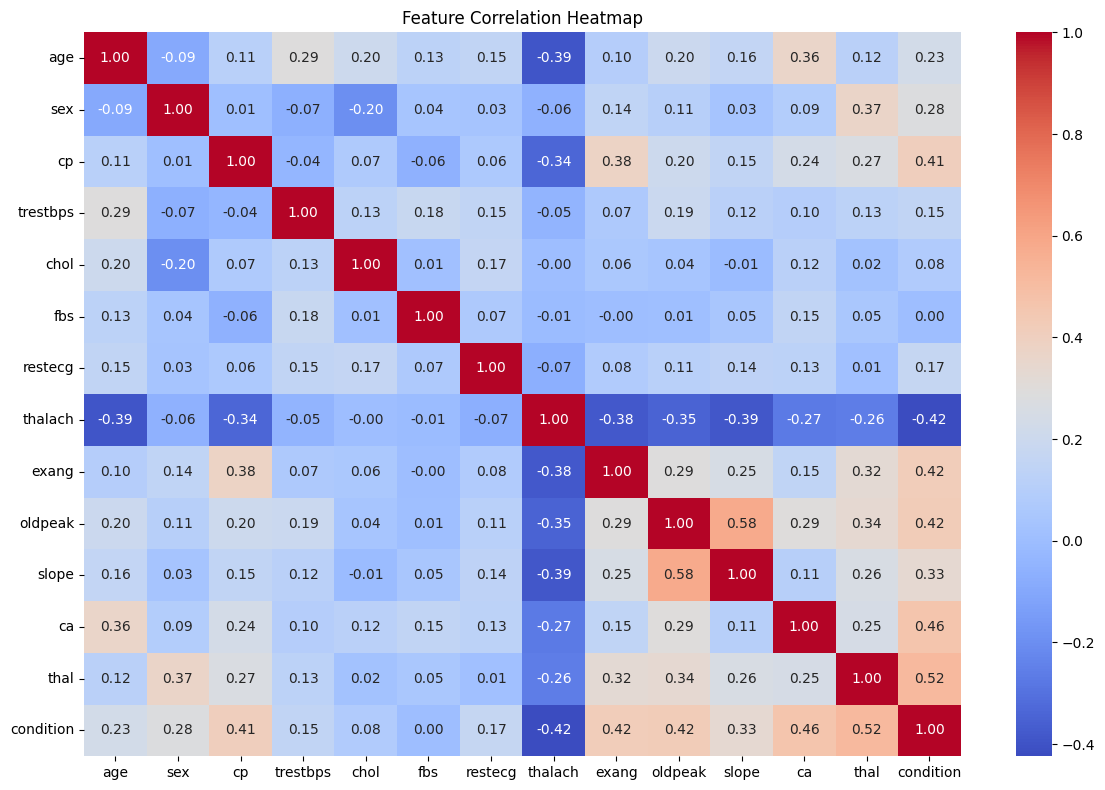

In [21]:
# CELL 7 — EDA: Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()
# INSIGHT: cp, thalach positively correlated with target
# exang, oldpeak, ca negatively correlated with target

In [22]:
# CELL 8 — Split features and condition
# X = all columns EXCEPT condition (these are inputs)
# y = condition column (this is what we predict)
X = df.drop(columns='condition')
y = df['condition']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target values:", y.unique())

X shape: (297, 13)
y shape: (297,)
Target values: [0 1]


In [23]:
# CELL 9 — Train/Test Split
# 80% data for training, 20% for testing
# random_state=42 means results are reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 237
Testing samples: 60


In [24]:
# CELL 10 — Train Logistic Regression model
# Logistic Regression is used for binary classification (yes/no problems)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [25]:
# CELL 11 — Evaluate model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")
# INSIGHT: Good accuracy is above 80% for this dataset

Accuracy: 73.33 %


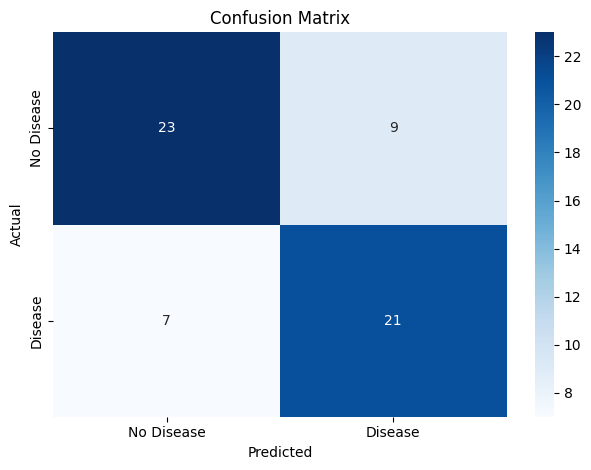

In [26]:
# CELL 12 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

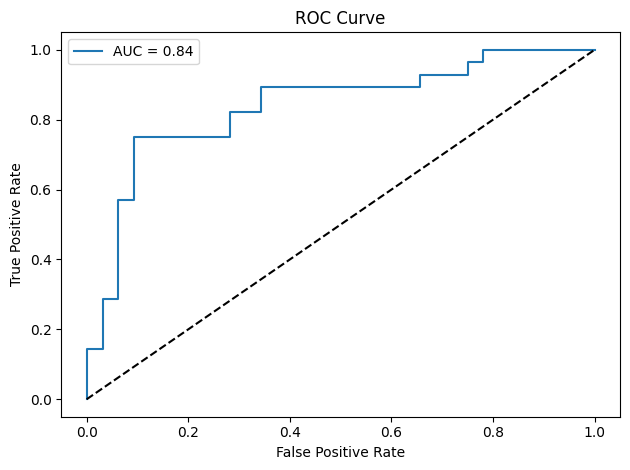

In [27]:
# CELL 13 — ROC Curve
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()
# INSIGHT: AUC closer to 1.0 = better model. Above 0.85 is good.

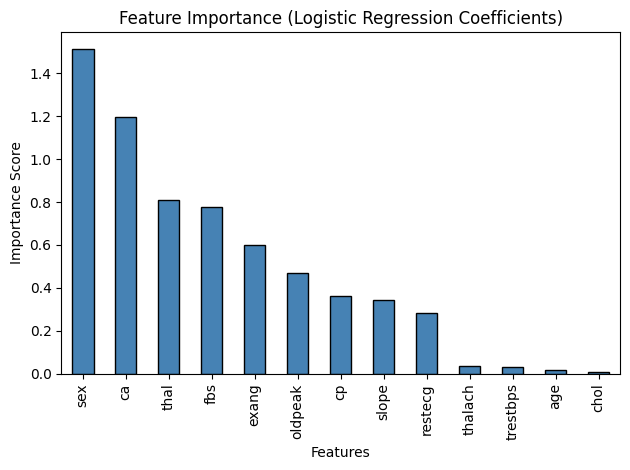

In [28]:
# CELL 14 — Feature Importance
# Which features matter most for prediction?
importance = pd.Series(
    np.abs(model.coef_[0]),
    index=X.columns
).sort_values(ascending=False)

importance.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()
# INSIGHT: cp (chest pain) and thalach (max heart rate) are typically top features

## Final Summary

- **Model:** Logistic Regression
- **Accuracy:** 73.33%
- **AUC Score:** 0.84
- **Top Features:** sex, ca, thal
- **Key Finding:** Gender and vessel blockage are 
  stronger predictors of heart disease than cholesterol 
  in this dataset.
- **False Negatives:** 7 patients with disease were 
  missed — in real medical use, this needs improvement.